# Full Demo of Stats

This notebook is to demonstrate stats not yet on the UI. The documentation for it including the development manifesto can be found [here](https://renalregistry.atlassian.net/wiki/spaces/UDF/pages/2308079624/Real-time+statistics+manifesto). 

In [4]:
from ukrdc.database import Connection
from sqlalchemy.orm import sessionmaker
import datetime as dt
import plotly.graph_objects as go

to_time = dt.datetime.now()
from_time = to_time - dt.timedelta(days=90)

engine = Connection.get_engine_from_file(key="ukrdc_staging")

ukrdc3_sessionmaker = sessionmaker(
    autocommit=False, autoflush=False, bind=engine
)

ukrdc3 = ukrdc3_sessionmaker()

# Kidney Replacement Therapy

The most important components of the update are the dialysis stats tabs. The first three relate to the numbers of patients under kidney replacement therapy. The plots should be explained by the descriptions which will appear on the UI with the stats.

In [5]:
from IPython.display import display, Markdown
from ukrdc_stats.descriptions import dialysis_descriptions

#from os import access
from ukrdc_stats.calculators.dialysis import DialysisStatsCalculator
import plotly.graph_objects as go
import plotly.express as px

import datetime as dt
#from IPython.display import display

import datetime as dt
"""
calculator = DialysisStatsCalculator(
    ukrdc3, "RNJ00", from_time=dt.datetime(2020, 9, 30), to_time=dt.datetime(2020, 12, 31)
)
"""

unit = "RK7CC"


calculator = DialysisStatsCalculator(
    ukrdc3, unit, from_time=dt.datetime(2023, 2, 1), to_time=dt.datetime(2023, 3, 1)
)


dialysis_stats = calculator.extract_stats()

print(list(dialysis_stats.units.keys()))
#print(dialysis_stats)





display(Markdown(dialysis_descriptions["ALL_PATIENTS_HOME_THERAPIES"]))
centre_text = f'Patient Count: {dialysis_stats.units.all.all_patients_home_therapies.metadata.population_size}'


# Use UKKA colors to 
label_colors = {'HD Home':"rgb(128,0,125)", 'HD In-centre':"rgb(156,28,76)", 'HD Unknown/Incomplete':"rgb(112,173,71)", 'PD':"rgb(54,142,205)", 'TX':"rgb(243,159,33)"}

all_patients = px.pie(
    names = dialysis_stats.units.all.all_patients_home_therapies.data.x,
    values = dialysis_stats.units.all.all_patients_home_therapies.data.y,
    hole=0.6,
    #color = label_colors.keys(),
    #color_discrete_map = label_colors,
)

all_patients.add_annotation(
    dict(x=0.5, y=0.5,  align='center', showarrow = False, text=centre_text)
)
all_patients.update_layout(title_text=dialysis_stats.units.all.all_patients_home_therapies.metadata.title, title_x=0.5)
all_patients.show()
#all_patients.show("png")


['RK7CC', 'RP5', 'Unknown/Incomplete', 'RFRAA', 'RFRPA', '9RK7CC', 'RFSDA', 'RRK02', '995', 'RF201', 'SNC01', 'RQR13', 'REP17', 'RHW01']


C:\Users\philip.main\Source\dashboard-stats\ukrdc_stats\calculators\dialysis.py:134: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  patient_cohort["qbl05"].replace(mappings, inplace=True)
C:\Users\philip.main\Source\dashboard-stats\ukrdc_stats\calculators\dialysis.py:134: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patient_cohort["qbl05"].rep


# All Patients Undergoing Kidney Replacement Therapy

## Overview
This pie chart illustrates the proportion of patients who received kidney replacement therapy within the time period. The chart is broken down by the type of treatment, including HD In-center, HD Home, HD Unknown/Incomplete, PD, and Tx. Optionally the chart can be filtered by satellite unit. 

## Treatment Definitions
- HD: Haemodialysis patients (with a modality defined as HD by the UKRDC). This includes patients registered for haemodialysis, haemofiltration, haemodiafiltration, or ultrafiltration. 
- PD: Peritoneal dialysis (with a modality defined as PD by the UKRDC).This includes patients registered for CAPD or APD treatments.
- TX: Transplant patients (with a modality defined as TX), including both living and cadaver donors.
- In-centre: HD patients with qbl05 field of the Treatment table as HOSP or SATL.   
- Home: HD patients with qbl05 field of the Treatment table as HOME. 
- Unknown/Incomplete: HD patients with incomplete qbl05 field or anything other than HOME, HOSP, or SATL

## Methodology 
- Any patients with a time of death before the beginning of the time window were excluded from the cohort, as were any patients whose treatments started before and ended after it.
- Patient's therapy types was selected using the admission reason and the unit, and were further split into home and in-center therapy groups (with all patients on PD included in the home therapies group).
- The numbers were calculated from aggregating patients within the five groups: HD Home, HD In-centre, HD Unknown/Incomplete, PD and TX.
- No deduplication is applied to the treatment records so patients with multiple treatments will be double counted

## UKRDC Entities Used
The chart was produced by joining the following UKRDC entities according to their foreign key relationships:
- [PatientRecord](https://renalregistry.atlassian.net/wiki/spaces/UD/pages/2006450149/PatientRecord): ukrdcid, sendingextract
- [Patient](https://renalregistry.atlassian.net/wiki/spaces/UD/pages/2006450145/Patient): deathtime
- [Treatment](https://renalregistry.atlassian.net/wiki/spaces/UD/pages/2006450155/Treatment+Encounter): qbl05, hdp04, fromtime, totime, dischargereasoncode, healthcarefacilitycode
- [ModalityCodes](https://renalregistry.atlassian.net/l/cp/Ac1YeFfH): registry_code_type


AttributeError: 'dict' object has no attribute 'all'

In [ ]:
display(Markdown(dialysis_descriptions["PREVALENT_HOME_THERAPIES"]))
centre_text = f'Patient Count: {dialysis_stats.units[satunit].prevalent_home_therapies.metadata.population_size}'

prev_patients = px.pie(
    names = dialysis_stats.units[satunit].prevalent_home_therapies.data.x,
    values = dialysis_stats.units[satunit].prevalent_home_therapies.data.y,
    hole=0.6,
    color = label_colors.keys(),
    color_discrete_map = label_colors,
)
prev_patients.add_annotation(
    dict(x=0.5, y=0.5,  align='center',showarrow = False,text=centre_text)
)
prev_patients.update_layout(title_text=dialysis_stats.units[satunit].prevalent_home_therapies.metadata.title, title_x=0.5)
prev_patients.show("png")




# Prevalent Patients Undergoing Kidney Replacement Therapy

## Overview
This pie chart illustrates the proportion of prevalent (to the end of the time window) patients who received kidney replacement therapy at a specified unit during a three-month period prior to the current date. The chart is broken down by type of treatment, including HD In-center, HD Home, HD Unknown/Incomplete, and PD. Optionally the chart can be filtered by satellite unit.

## Treatment Definitions
- HD: Haemodialysis patients (with a modality defined as HD by the UKRDC). This includes patients registered for haemodialysis, haemofiltration, haemodiafiltration, or ultrafiltration. 
- PD: Peritoneal dialysis (with a modality defined as PD by the UKRDC).This includes patients registered for CAPD or APD treatments.
- TX: Transplant patients (with a modality defined as TX), including both living and cadaver donors.
- In-centre: HD patients with qbl05 field of the Treatment table as HOSP or SATL.   
- Home: HD patients with qbl05 field of the Treatment table as HOME. 
- Unknown/Incomplete: HD patients with incomplete qbl05 field or anything other than HOME, HOSP, or SATL

## Study Methods
- The cohort was created from all patients admitted for HD or PD (as defined by the modality code mappings) at the specified unit or satellite unit.
- Any patients with a time of death before the beginning of the time window were excluded from the cohort, as were any patients whose treatments started before and ended after it.
- Any patient with a treatment to time or date of death before todays date are excluded
- Any patient with a transplant or dialysis treatment prior to the beginning of the time window was excluded.
- The numbers were calculated from the Patient and Treatment records in the UKRDC.
- Patient's therapy types was selected using the admission reason and the unit, and were further split into home and in-center therapy groups (with all patients on PD included in the home therapies group).
- Where there are multiple treatment modalities which overlap with the end of the time window the one with the most recent end date is selected. 

## UKRDC Entities Used
The chart was produced by joining the following UKRDC entities according to their foreign key relationships:
- [PatientRecord](https://renalregistry.atlassian.net/wiki/spaces/UD/pages/2006450149/PatientRecord): ukrdcid, sendingextract
- [Patient](https://renalregistry.atlassian.net/wiki/spaces/UD/pages/2006450145/Patient): deathtime
- [Treatment](https://renalregistry.atlassian.net/wiki/spaces/UD/pages/2006450155/Treatment+Encounter): qbl05, hdp04, fromtime, totime, dischargereasoncode, healthcarefacilitycode
- [ModalityCodes](https://renalregistry.atlassian.net/l/cp/Ac1YeFfH): registry_code_type


KeyError: 'all'

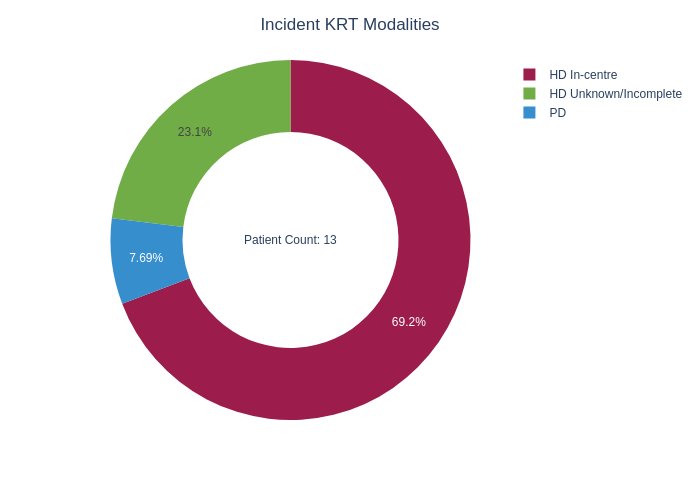

In [ ]:
#display(Markdown(dialysis_descriptions["INCIDENT_HOME_THERAPIES"]))
centre_text = f'Patient Count: {dialysis_stats.units[satunit].incident_home_therapies.metadata.population_size}'
colors = {key: label_colors[key] for key in dialysis_stats.units[satunit].incident_home_therapies.data.x}


incident_patients = px.pie(
    names = dialysis_stats.units[satunit].incident_home_therapies.data.x,
    values = dialysis_stats.units[satunit].incident_home_therapies.data.y,
    hole=0.6,
    color = colors.keys(),
    color_discrete_map = colors,
)
incident_patients.add_annotation(
    dict(x=0.5, y=0.5,  align='center', showarrow = False, text=centre_text)
)
incident_patients.update_layout(title_text=dialysis_stats.units[satunit].incident_home_therapies.metadata.title, title_x=0.5)

incident_patients.show("png")


# In-Centre Dialysis Frequency

## Overview
This histogram represents the mean number of dialysis sessions per week for all dialysis patients in a three month period at a sendingfacility or one of its satellites. Optionally the chart can be filtered by satellite unit. 

## Methodology
- Dialysis sessions are counted for patients in the 'All Patients Undergoing Kidney Replacement Therapy' cohort. This is done by grouping on the procedure type code. 
- Patients with less than two sessions are rejected. 
- The per week frequency is calculated for each person by dividing the count by the time difference between their first and last dialysis session within the three month period.
- Patients are aggregated into bins of with boundaries (0.5, 1.5, 2.5, 3.5, 7.0). This are labelled 1,2,3 and >3 sessions per week.  

## UKRDC Entities Used
The dialysis sessions table is queried by grouping by ukrdcid with the following aggregate functions used:
- https://renalregistry.atlassian.net/wiki/spaces/UD/pages/2005565449/Dialysis+Session+Procedure: MIN(fromtime), MAX(totime), COUNT(sessiontype).


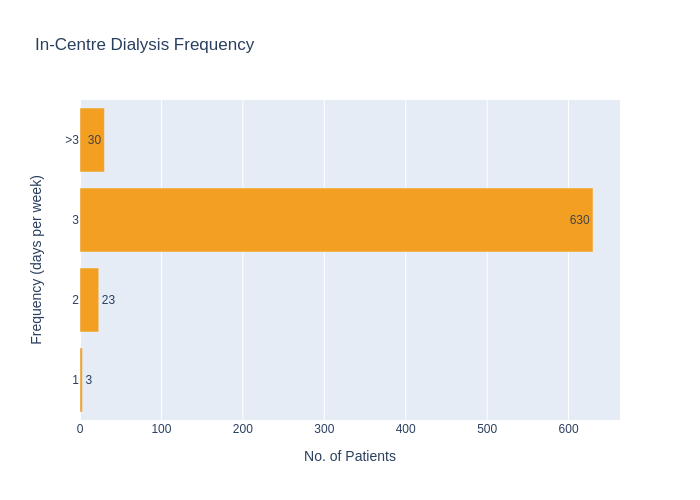

In [ ]:
#satunit = "9RNJ00"
satunit = "all"

display(Markdown(dialysis_descriptions["INCENTRE_DIALYSIS_FREQ"]))
freq_fig = px.bar(
    x=dialysis_stats.units[satunit].incentre_dialysis_frequency.data.y,
    y=dialysis_stats.units[satunit].incentre_dialysis_frequency.data.x,
    title=dialysis_stats.units[satunit].incentre_dialysis_frequency.metadata.title,
    labels={
        "x": dialysis_stats.units[satunit].incentre_dialysis_frequency.metadata.axis_titles.y,
        "y": dialysis_stats.units[satunit].incentre_dialysis_frequency.metadata.axis_titles.x,
    },
    orientation="h",
    color_discrete_sequence=["rgb(243,159,33)"],
    text_auto=True,
)

freq_fig.show("png")




 # Incident Initial Access
 ## Overview
 This pie chart shows the vascular access recorded on the first dialysis session of each incident patient. Optionally the chart can be filtered by satellite unit.

 ## Methodology
 - This cohort is identical to that used for incident patients treatment breakdown.
 - The first session is selected by ranking the dialysis sessions in time.
 - If the type of vascular access has been recorded it is counted accordingly otherwise it is counted as Unknown/Incomplete.

## UKRDC Entities Used
 - [Dialysis Session](https://renalregistry.atlassian.net/wiki/spaces/UD/pages/2005565449/Dialysis+Session+Procedure) qhd20 for first dialysis session. 


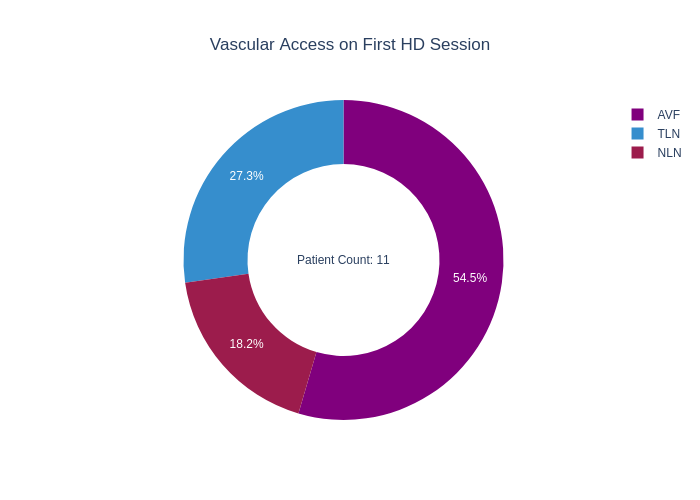

In [ ]:
display(Markdown(dialysis_descriptions["INCIDENT_INITIAL_ACCESS"]))
label_colors = {'AVF': "rgb(128,0,125)",'AVG':"rgb(112,173,71)", 'NLN':"rgb(156,28,76)", "TLN":"rgb(54,142,205)", "DoesNotContain":"rgb(0,0,0)"}

colors = {key: label_colors[key] for key in dialysis_stats.units[satunit].incident_initial_access.data.x}


#print(colors)
#print(dialysis_stats.units[satunit].incident_initial_access.data.x)

centre_text = f'Patient Count: {dialysis_stats.units[satunit].incident_initial_access.metadata.population_size}'
access_fig = px.pie(
    values=dialysis_stats.units[satunit].incident_initial_access.data.y,
    names=dialysis_stats.units[satunit].incident_initial_access.data.x,
    title=dialysis_stats.units[satunit].incident_initial_access.metadata.title,
    hole=0.6,
    color = colors.keys(),
    color_discrete_map = colors,
)
access_fig.add_annotation(
    dict(x=0.5, y=0.5,  align='center',showarrow = False, text=centre_text)
)
access_fig.update_layout( title_x=0.5)




access_fig.show("png")